In [ ]:
from motion_types import CreateMotion
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
fs = 1000 # sampling frequency
duration = 1.0   # seconds (the whole duration of the motion in the session)

# Time vector
t = np.arange(int(duration * fs)) / fs

freq = 2.0       # sinus frequency (Hz)
amplitude = 1.0  # sinus amplitude

In [ ]:
class Anxiety:
    def __init__(self, a_baseline):
        self.A_baseline = a_baseline
        self.A = 0
        self.A_history = np.array([])

    
    def instantaneous_anxiety(self, beta, mismatch):
        self.A = self.A_baseline + beta*mismatch

        return self.A
    
    def predictive_model(self, t_array):
        create_motion = CreateMotion() 
        motion_model = np.array(create_motion._smooth_motion(t=t_array))
        
        return motion_model
        
    def calculate_instantaneous_mismatch(self, signal, t_inst, t_array):
        index = int(t_inst * fs)   # convert time to sample index
        expected_signal = self.predictive_model(t_array)[index]
        
        inst_mismatch = expected_signal - signal
        
        
        return inst_mismatch
        
    def calculate_mse(self, signals, t):
        expected_signal = self.predictive_model(t)
        mse = mean_squared_error(expected_signal, np.array(signals))
        
        return mse
        
        


In [ ]:
def test_motions():
    motion = CreateMotion()

    # Different motions
    baseline = motion.motion(t=t, start_time=0.0, motion_type="smooth", freq=freq, amplitude=amplitude)
    vib_delta = motion.motion(
            t=t,
            start_time=duration*0.45,
            motion_type="vibration",
            burst_start_time=duration*0.45,
            burst_freq=50.0,
            duration=0.10,
            amplitude=0.5,
        )

    plt.figure(figsize=(10, 5))
    plt.plot(t, baseline, color="blue", label="Baseline Smooth")
    plt.plot(t, vib_delta,  color="green", label="Lag Low")


    plt.xlabel("Time (s)")
    plt.ylabel("Acceleration (a.u.)")
    plt.title("Motion Profiles")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

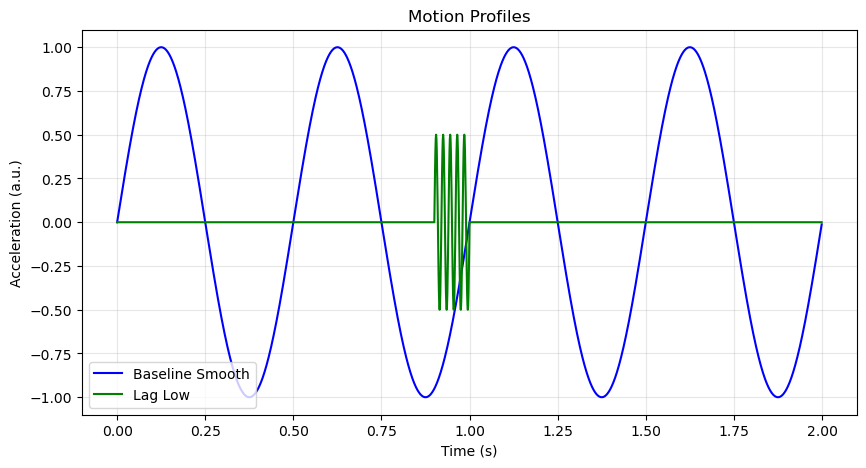

In [ ]:
test_motions()

In [ ]:
def test():
    a = Anxiety(20)
        # Parameters
    motion = CreateMotion()
    
    baseline = motion.motion(
        t=t,
        start_time=0.0,
        motion_type="smooth",
        freq=freq,
        amplitude=amplitude,
    )
    vib_delta = motion.motion(
        t=t,
        start_time=duration*0.45,
        motion_type="vibration",
        burst_start_time=duration*0.45,
        burst_freq=50.0,
        duration=0.10,
        amplitude=0.5,
    )
    vib = baseline + vib_delta
    
    mismatch_arr = []
    for t_inst in t:
        mismatch = a.calculate_instantaneous_mismatch(vib[t_inst], t_inst ,t)
        mismatch_arr.append(mismatch)


    return baseline, vib_delta, np.array(mismatch_arr)
  

In [ ]:
baseline, vib_delta, mismatch_arr = test()
print(mismatch_arr.shape())


# plt.figure(figsize=(10, 5))
# plt.plot(t, baseline, color="blue", label="Baseline Smooth")
# plt.plot(t, vib_delta,  color="green", label="vib_delta")
# plt.plot(t, mismatch_arr,  color="red", label="mismatch_arr")


# plt.xlabel("Time (s)")
# plt.ylabel("Acceleration (a.u.)")
# plt.title("Motion Profiles")
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()
